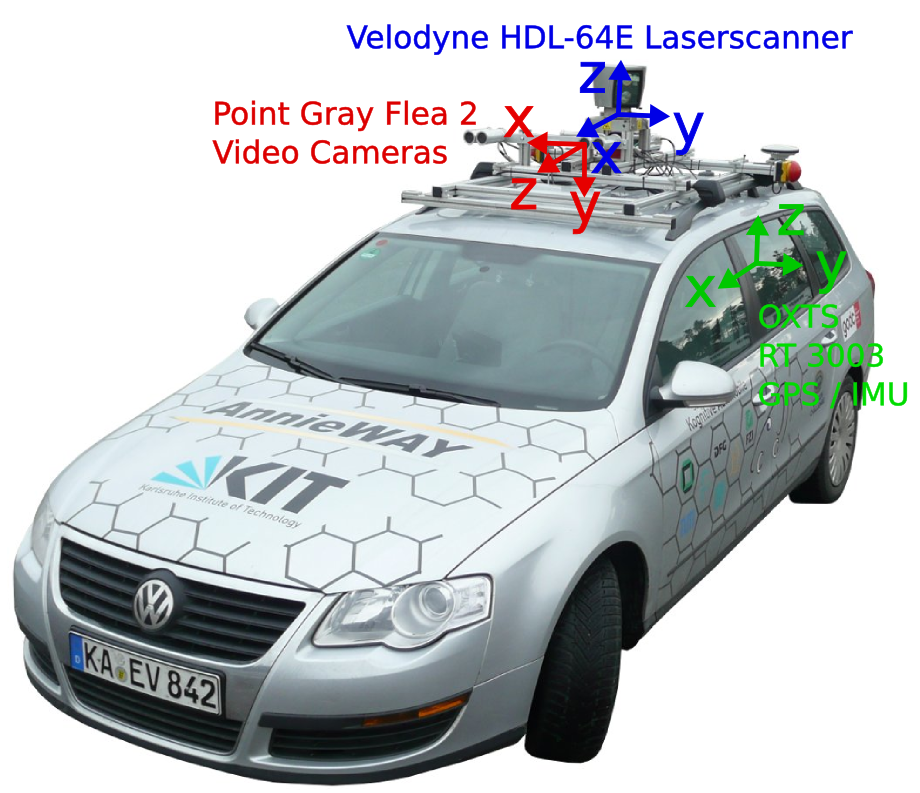

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


- Bloc 0 : Installation et Importations
Ce bloc prépare l'environnement de travail.

In [ ]:
# Installation des bibliothèques nécessaires
!pip install ultralytics open3d

import numpy as np
import cv2
import os
from ultralytics import YOLO
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.8 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings 

- Bloc 1 : Configuration et Calibration
Ce bloc définit les paramètres de transformation pour passer du monde 3D (LiDAR) au monde 2D (Caméra).

Note : Les matrices ci-dessous sont les standards du dataset KITTI.

In [ ]:
import os
import random

# Base directories
BASE_PATH = "/content/drive/MyDrive/fusion_project/fusion_project"
IMG_DIR = os.path.join(BASE_PATH, "data_object_image_2/training/image_2")
VELO_DIR = os.path.join(BASE_PATH, "velodyne_points/data")

# Get all valid image-LiDAR pairs
valid_pairs = []
for img_file in os.listdir(IMG_DIR):
    if not img_file.endswith(".png"):
        continue
    img_number = os.path.splitext(img_file)[0]           # e.g., '000005'
    img_path = os.path.join(IMG_DIR, img_file)

    # Convert to 10-digit LiDAR filename
    velo_number = img_number.zfill(10)                   # '0000000005'
    velo_path = os.path.join(VELO_DIR, f"{velo_number}.bin")

    if os.path.exists(img_path) and os.path.exists(velo_path):
        valid_pairs.append((img_path, velo_path))

if len(valid_pairs) < 5:
    raise ValueError("Not enough valid image-LiDAR pairs to select 5.")

# Randomly select 5 pairs
selected_pairs = random.sample(valid_pairs, 5)

# Print selected pairs
for img, velo in selected_pairs:
    print(f"Image: {img}, LiDAR: {velo}")


Image: /content/drive/MyDrive/fusion_project/fusion_project/data_object_image_2/training/image_2/000021.png, LiDAR: /content/drive/MyDrive/fusion_project/fusion_project/velodyne_points/data/0000000021.bin
Image: /content/drive/MyDrive/fusion_project/fusion_project/data_object_image_2/training/image_2/000060.png, LiDAR: /content/drive/MyDrive/fusion_project/fusion_project/velodyne_points/data/0000000060.bin
Image: /content/drive/MyDrive/fusion_project/fusion_project/data_object_image_2/training/image_2/000004.png, LiDAR: /content/drive/MyDrive/fusion_project/fusion_project/velodyne_points/data/0000000004.bin
Image: /content/drive/MyDrive/fusion_project/fusion_project/data_object_image_2/training/image_2/000035.png, LiDAR: /content/drive/MyDrive/fusion_project/fusion_project/velodyne_points/data/0000000035.bin
Image: /content/drive/MyDrive/fusion_project/fusion_project/data_object_image_2/training/image_2/000078.png, LiDAR: /content/drive/MyDrive/fusion_project/fusion_project/velodyne_po

- Bloc 2 : Détection d'Objets (Vision 2D)
On utilise YOLOv8 pour obtenir les boîtes englobantes sur l'image.

In [ ]:
from ultralytics import YOLO

def detect_objects(image_path):
    model = YOLO('yolov8n.pt')
    img = cv2.imread(image_path)
    results = model(img, verbose=False)

    detections = []
    for result in results:
        for box in result.boxes:
            detections.append({
                'bbox': list(map(int, box.xyxy[0])),
                'label': model.names[int(box.cls[0])]
            })
    return img, detections

- Bloc 3 : Traitement LiDAR et Projection
Ce bloc convertit les points 3D en coordonnées pixels 2D.

In [ ]:
def project_lidar_to_2d(velo_path, P2, Tr_velo_to_cam):
    # Chargement du fichier .bin
    scan = np.fromfile(velo_path, dtype=np.float32).reshape((-1, 4))
    points_3d = scan[:, :3]

    # Ajout d'une colonne de 1 pour le calcul matriciel (coordonnées homogènes)
    pts_3d_homo = np.hstack((points_3d, np.ones((points_3d.shape[0], 1))))

    # Transformation vers le repère caméra
    pts_3d_cam = (Tr_velo_to_cam @ pts_3d_homo.T)

    # Filtrage : On ne garde que ce qui est devant la voiture (Z > 0)
    front_mask = pts_3d_cam[2, :] > 0
    pts_3d_cam = pts_3d_cam[:, front_mask]

    # Projection finale sur les pixels de l'image
    pts_2d = P2 @ pts_3d_cam
    pts_2d[:2, :] /= pts_2d[2, :]

    return pts_2d[:2, :].T, pts_3d_cam[2, :]

- Bloc 4 : Fusion et Calcul de Distance
Le bloc final qui associe les points LiDAR aux boîtes YOLO pour calculer la distance réelle.

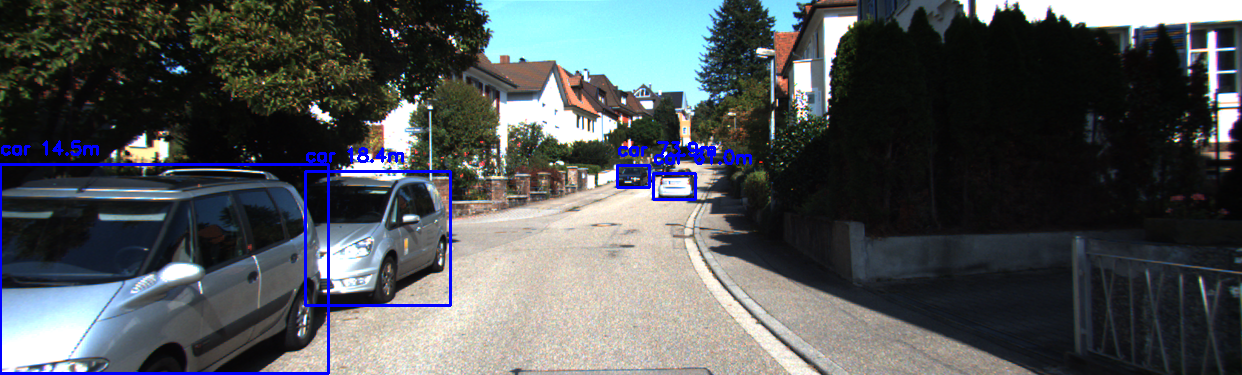

In [ ]:
def run_fusion():
    # Paramètres de calibration KITTI
    P2 = np.array([[721.35, 0, 609.55, 44.85], [0, 721.35, 172.85, 0.21], [0, 0, 1, 0.002]])
    # Ajout d'une ligne pour rendre Tr_velo_to_cam 4x4
    Tr_velo_to_cam_4x4 = np.array([
        [7.53e-03, -9.99e-01, -3.61e-04, -4.06e-03],
        [1.48e-02, 7.28e-04, -9.99e-01, -7.63e-02],
        [9.99e-01, 7.52e-03, 1.48e-02, -2.71e-01],
        [0, 0, 0, 1]
    ])

    for img_path, velo_path in selected_pairs:
        image, detections = detect_objects(img_path)
        pts_2d, depths = project_lidar_to_2d(velo_path, P2, Tr_velo_to_cam_4x4)

        for obj in detections:
            x1, y1, x2, y2 = obj['bbox']
            in_box = (pts_2d[:, 0] > x1) & (pts_2d[:, 0] < x2) & \
                 (pts_2d[:, 1] > y1) & (pts_2d[:, 1] < y2)
            if np.any(in_box):
               distance = np.median(depths[in_box])
               cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
               cv2.putText(image, f"{obj['label']} {distance:.1f}m",
                        (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    cv2_imshow(image)
# EXECUTION
run_fusion()